# Does the VLM pipeline work? A 10-participant check on PITT

This notebook takes **10 PITT participants** (5 with an autism diagnosis, 5 controls) and
asks one question of pipeline B, the vision-language model (VLM) in `src/vlm_*.py`:
*can the pipeline, as written, learn these ten people?*

1. **Look at the data**: the original fMRI slices and *everything* the model receives
   (the picture tensors, the text reports, the token ids).
2. **Train until it fits**: deliberately over-train on these ten participants, on exactly
   the slices they are later evaluated on, and plot every loss term at every step. "Fits"
   means every participant is classified correctly *and* at least 80% of their individual
   slices are.
3. **Save, reload, re-predict**: save the trained model, load it into a fresh model, and
   check the predictions are identical, with the diagnosis removed from every record.
4. **Verdict**: a PASS/FAIL table, and if anything fails, a diagnosis written to
   `results/pitt10_check/report.md`.

Why this is a useful check: a model that cannot even memorise ten people it has seen has a
broken pipeline (data loading, picture-report pairing, the losses, or the evaluation),
not a hard problem. Passing says **nothing** about generalising to new people; that is
what the cross-validated experiment in `src/vlm_experiment.py` measures.

Settings follow the laptop defaults (140 px, batch 32, gradient
checkpointing). Set the environment variable `PITT10_QUICK=1` to run the whole notebook
in a few minutes with almost no training, to check the code rather than the model.

In [1]:
import os
import subprocess
import sys
import time
import warnings
from pathlib import Path

os.environ.setdefault("HF_HUB_OFFLINE", "1")  # the two towers are in the local cache; never wait on the network
warnings.filterwarnings("ignore", message="IProgress not found")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))

import download  # noqa: E402
import vlm_experiment  # noqa: E402
import vlm_model  # noqa: E402
import vlm_reports  # noqa: E402
import vlm_slices  # noqa: E402
import transformers  # noqa: E402

transformers.utils.logging.set_verbosity_error()  # hide the expected 'unexpected keys' report of BERT's pre-training head
transformers.utils.logging.disable_progress_bar()

QUICK = os.environ.get("PITT10_QUICK") == "1"
SEED = 0
IMAGE_SIZE = vlm_model.DEFAULT_IMAGE_SIZE  # 140 px
BATCH = 32
PLANES = list(vlm_slices.PLANES)
STEPS_PER_ROUND = 5 if QUICK else 250
MAX_ROUNDS = 1 if QUICK else 3
N_TIMEPOINTS_EVAL = 1 if QUICK else 4  # time points per participant, for training AND evaluation (see section 3)
SLICE_TARGET = 0.8  # 'fits' = every participant correct and at least this fraction of their individual slices
OUT = ROOT / "results" / "pitt10_check"
OUT.mkdir(parents=True, exist_ok=True)

device = vlm_model.pick_device()
commit = subprocess.run(["git", "rev-parse", "--short", "HEAD"], cwd=ROOT, capture_output=True, text=True).stdout.strip()
dirty = bool(subprocess.run(["git", "status", "--porcelain"], cwd=ROOT, capture_output=True, text=True).stdout.strip())
print(f"commit {commit}{' (dirty)' if dirty else ''} | torch {torch.__version__} on {device} | quick mode: {QUICK}")
print(f"{STEPS_PER_ROUND} steps per round, up to {MAX_ROUNDS} rounds, {N_TIMEPOINTS_EVAL} time point(s) per participant")

commit 44ff0f4 (dirty) | torch 2.14.0 on mps | quick mode: False
250 steps per round, up to 3 rounds, 4 time point(s) per participant


## 1. The ten participants

PITT is one ABIDE site (University of Pittsburgh). `src/vlm_slices.py` has already cut 50
PITT recordings into slice banks under `data/slices/`. We take the five lowest-ID autistic
participants and the five lowest-ID controls among them: a fixed, reproducible choice, not
a hand-picked one.

`label` is what the rest of the project uses: 1 = autism spectrum disorder (ABIDE `DX_GROUP`
1), 0 = typical control (`DX_GROUP` 2).

In [2]:
phenotypic = pd.read_csv(download.DATA_DIR / "ABIDE_pcp" / "Phenotypic_V1_0b_preprocessed1.csv")
on_disk = {p.stem for p in vlm_slices.SLICES_DIR.glob("*.npz")}
pitt = phenotypic[(phenotypic["SITE_ID"] == "PITT") & phenotypic["FILE_ID"].isin(on_disk)].sort_values("FILE_ID")
chosen = pd.concat([pitt[pitt["DX_GROUP"] == 1].head(5), pitt[pitt["DX_GROUP"] == 2].head(5)]).reset_index(drop=True)
file_ids = chosen["FILE_ID"].tolist()
y, sites = download.phenotypic_targets(chosen)
rows = {fid: chosen.iloc[i] for i, fid in enumerate(file_ids)}
banks = vlm_slices.load_slices(file_ids)
assert len(banks) == 10 and y.tolist() == [1] * 5 + [0] * 5, (len(banks), y)

table = chosen[["FILE_ID", "DX_GROUP", "AGE_AT_SCAN", "SEX", "HANDEDNESS_CATEGORY", "EYE_STATUS_AT_SCAN", "FIQ", "ADOS_TOTAL"]]
table = table.assign(label=y, n_timepoints_total=[int(banks[f]["n_timepoints_total"]) for f in file_ids])
table.to_csv(OUT / "participants.csv", index=False)
display(table)
shape = banks[file_ids[0]]["axial"].shape
print(f"each bank: {len(PLANES)} planes x {shape[0]} time points x {shape[1]} slices of {shape[2]}x{shape[3]} uint8 pixels")

,FILE_ID,DX_GROUP,AGE_AT_SCAN,SEX,HANDEDNESS_CATEGORY,EYE_STATUS_AT_SCAN,FIQ,ADOS_TOTAL,label,n_timepoints_total
0,Pitt_0050003,1,24.45,1,R,2,124.0,13.0,1,196
1,Pitt_0050004,1,19.09,1,R,2,113.0,18.0,1,196
2,Pitt_0050005,1,13.73,2,R,2,119.0,12.0,1,196
3,Pitt_0050006,1,13.37,1,L,2,109.0,12.0,1,196
4,Pitt_0050007,1,17.78,1,R,2,110.0,17.0,1,196
5,Pitt_0050030,2,25.12,1,-9999,2,105.0,NaN,0,196
6,Pitt_0050031,2,12.92,1,R,2,106.0,NaN,0,196
7,Pitt_0050032,2,19.80,1,R,2,119.0,NaN,0,196
8,Pitt_0050033,2,12.15,1,R,2,98.0,NaN,0,196
9,Pitt_0050034,2,14.77,1,R,2,97.0,NaN,0,196


each bank: 3 planes x 16 time points x 7 slices of 76x76 uint8 pixels


## 2. The original slices

C-PAC's `func_preproc` volumes are **residuals** after nuisance regression, so every voxel's
signal has zero mean over the recording. One time point of such a volume is therefore not
a picture of anatomy: it is a map of where the BOLD signal is *above or below its own mean
at that instant*, inside the brain mask. The slice bank stores each slice as an 8-bit
image: the volume is scaled by its in-mask standard deviation, clipped at ±3 SD, and mapped
to 0..255 with zero signal at mid-grey (128).

Left: a raw slice straight from the 4D NIfTI file (when the 100 MB file is still on disk;
most are deleted after slicing). Right: the stored 8-bit version the pipeline uses.

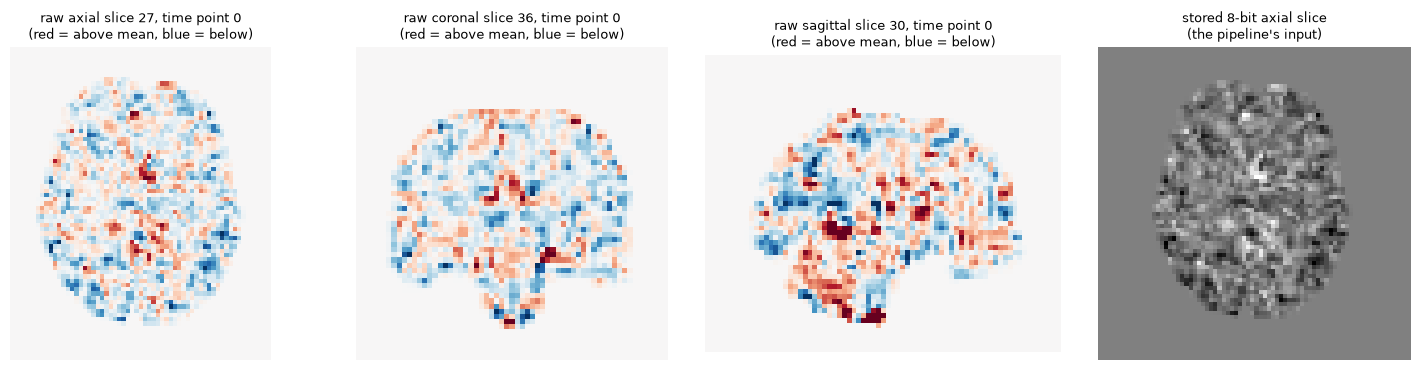

Pitt_0050003: volume (61, 73, 61, 196), 67431 brain voxels, in-mask values at t=0: mean -11.186, SD 60.926


In [3]:
import nibabel as nib

raw_id = next((fid for fid in file_ids if vlm_slices.volume_path(fid).exists()), None)
if raw_id is None:
    print("No raw 4D volume on disk for these participants (they are deleted after slicing); skipping.")
else:
    volume = np.asarray(nib.load(vlm_slices.volume_path(raw_id)).dataobj, dtype=np.float32)
    bank = banks[raw_id]
    t = int(bank["timepoints"][0])
    mask = vlm_slices.brain_mask(volume)
    sd = float(volume[..., t][mask].std())
    fig, axes = plt.subplots(1, 4, figsize=(15, 3.8))
    for ax, plane in zip(axes[:3], PLANES):
        index = int(bank[f"{plane}_index"][3])
        raw = np.rot90(np.take(volume[..., t], index, axis=vlm_slices.PLANE_AXIS[plane]))
        ax.imshow(raw, cmap="RdBu_r", vmin=-3 * sd, vmax=3 * sd)
        ax.set_title(f"raw {plane} slice {index}, time point {t}\n(red = above mean, blue = below)", fontsize=9)
        ax.axis("off")
    axes[3].imshow(bank["axial"][0, 3], cmap="gray", vmin=0, vmax=255)
    axes[3].set_title("stored 8-bit axial slice\n(the pipeline's input)", fontsize=9)
    axes[3].axis("off")
    plt.tight_layout()
    plt.show()
    print(f"{raw_id}: volume {volume.shape}, {int(mask.sum())} brain voxels, "
          f"in-mask values at t={t}: mean {volume[..., t][mask].mean():+.3f}, SD {sd:.3f}")

All ten participants: the middle slice of each plane at the first stored time point.
There is nothing to see by eye that separates the two groups, and that is expected.

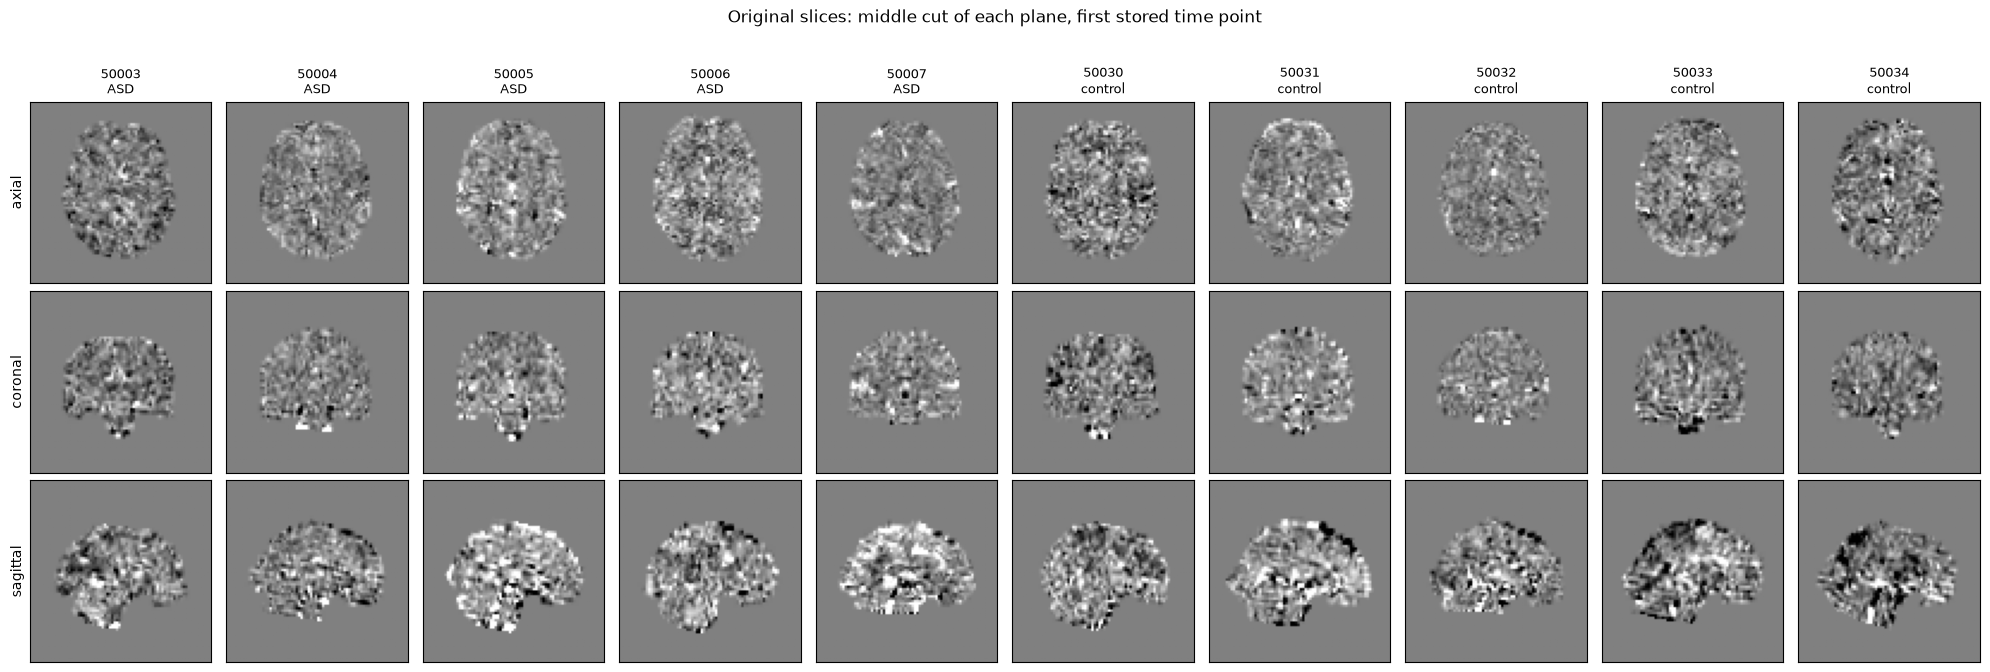

In [4]:
fig, axes = plt.subplots(3, 10, figsize=(20, 6.6))
for col, fid in enumerate(file_ids):
    for row, plane in enumerate(PLANES):
        ax = axes[row, col]
        ax.imshow(banks[fid][plane][0, 3], cmap="gray", vmin=0, vmax=255)
        ax.set_xticks([])
        ax.set_yticks([])
        if row == 0:
            ax.set_title(f"{fid.replace('Pitt_00', '')}\n{'ASD' if y[col] else 'control'}", fontsize=9)
        if col == 0:
            ax.set_ylabel(plane)
plt.suptitle("Original slices: middle cut of each plane, first stored time point", y=1.02)
plt.tight_layout()
plt.show()

One slice through time. The same axial cut of one participant at eight of the 16 stored
time points: the pattern changes from instant to instant because it is signal, not
structure. The model sees each of these as a separate picture.

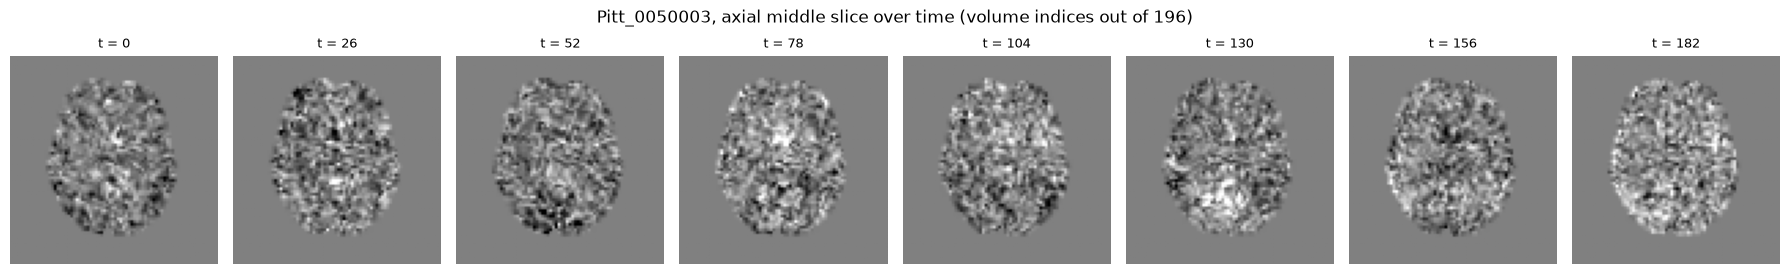

In [5]:
fid = file_ids[0]
timepoints = banks[fid]["timepoints"]
fig, axes = plt.subplots(1, 8, figsize=(18, 2.8))
for ax, k in zip(axes, range(0, 16, 2)):
    ax.imshow(banks[fid]["axial"][k, 3], cmap="gray", vmin=0, vmax=255)
    ax.set_title(f"t = {int(timepoints[k])}", fontsize=9)
    ax.axis("off")
plt.suptitle(f"{fid}, axial middle slice over time (volume indices out of {int(banks[fid]['n_timepoints_total'])})")
plt.tight_layout()
plt.show()

## 3. Exactly what the model receives

The model has two towers. The **picture tower** (DINOv2, a vision transformer) receives a
`(3, 140, 140)` float tensor: the 76×76 slice resized to 140 px, copied into three identical
colour channels, and normalised with ImageNet's mean and standard deviation. During
training each slice is also fed as a *second view*, the same slice under a different random
rotation, zoom and shift; the picture-to-picture loss asks the model to recognise the two
as the same picture.

To make memorisation reachable on a laptop, training uses only the `N_TIMEPOINTS_EVAL`
evenly spaced time points per participant that the evaluation uses (4 of the 16 stored, so
840 slices instead of 3360). The slices the model is trained on are therefore exactly the
slices it is later asked to classify: a deliberate overfit, which is the point of this check.

The **text tower** (Bio_ClinicalBERT with LoRA adapters) receives a report written from
the phenotypic table: sentences joined with `[SEP]`, tokenised to integer ids. During
training, each personal detail (site, age, sex, handedness, eyes, IQ) is blanked with
probability 0.8, so the model cannot shortcut by memorising the metadata. The findings and
impression sentences, which carry the diagnosis, are never blanked.

840 training examples = 10 participants x 3 planes x 4 time points (stored indices [0, 5, 10, 15]) x 7 slices
picture tensor: shape (1, 3, 140, 140), torch.float32, min -1.91, max 2.31, mean 0.26
the three colour channels are identical grey copies before the per-channel ImageNet normalisation: True


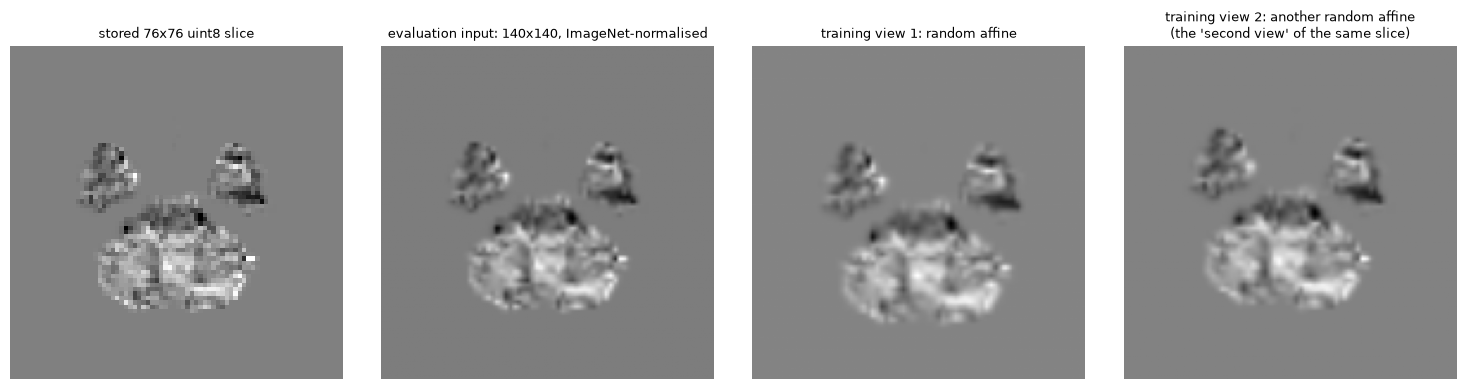

In [6]:
train_index = vlm_slices.pick_timepoints(16, N_TIMEPOINTS_EVAL)  # the same time points vlm_experiment.subject_slices evaluates
train_banks = {
    fid: {**bank, "timepoints": bank["timepoints"][train_index], **{plane: bank[plane][train_index] for plane in PLANES}}
    for fid, bank in banks.items()
}
dataset = vlm_experiment.PairDataset(train_banks, rows, file_ids, PLANES, pair_mode="self", mask_prob=vlm_reports.MASK_PROB, seed=SEED)
print(f"{len(dataset)} training examples = 10 participants x {len(PLANES)} planes x {len(train_index)} time points "
      f"(stored indices {train_index.tolist()}) x 7 slices")

item = dataset[0]
generator = torch.Generator().manual_seed(SEED)
plain = vlm_model.prepare_images(item["view1"][None], IMAGE_SIZE)
view1 = vlm_model.prepare_images(item["view1"][None], IMAGE_SIZE, augment=True, generator=generator)
view2 = vlm_model.prepare_images(item["view2"][None], IMAGE_SIZE, augment=True, generator=generator)
print(f"picture tensor: shape {tuple(view1.shape)}, {view1.dtype}, min {view1.min():.2f}, max {view1.max():.2f}, mean {view1.mean():.2f}")
grey = plain[0] * torch.tensor(vlm_model.IMAGENET_STD).view(3, 1, 1) + torch.tensor(vlm_model.IMAGENET_MEAN).view(3, 1, 1)
print("the three colour channels are identical grey copies before the per-channel ImageNet normalisation:",
      bool(torch.allclose(grey[0], grey[1], atol=1e-6) and torch.allclose(grey[1], grey[2], atol=1e-6)))

fig, axes = plt.subplots(1, 4, figsize=(15, 3.8))
panels = [
    (item["view1"], "stored 76x76 uint8 slice", dict(cmap="gray", vmin=0, vmax=255)),
    (plain[0, 0], "evaluation input: 140x140, ImageNet-normalised", dict(cmap="gray")),
    (view1[0, 0], "training view 1: random affine", dict(cmap="gray")),
    (view2[0, 0], "training view 2: another random affine\n(the 'second view' of the same slice)", dict(cmap="gray")),
]
for ax, (image, title, kw) in zip(axes, panels):
    ax.imshow(np.asarray(image), **kw)
    ax.set_title(title, fontsize=9)
    ax.axis("off")
plt.tight_layout()
plt.show()

Building the model loads the two pre-trained towers from the local Hugging Face cache (no
download). The text tower's base weights are frozen; only its LoRA adapters, the whole
picture tower, the four projection heads and the CLIP temperature are trained.

In [7]:
def build_model():
    torch.manual_seed(SEED)
    return vlm_model.MaMA(grad_checkpointing=True)


t0 = time.time()
model = build_model().to(device)
n_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
n_total = sum(p.numel() for p in model.parameters())
print(f"model built in {time.time() - t0:.0f} s: {n_trainable / 1e6:.1f}M trainable of {n_total / 1e6:.1f}M parameters")
print("trainable parts:", sorted({name.split('.')[0] for name, p in model.named_parameters() if p.requires_grad}))

model built in 1 s: 22.9M trainable of 131.3M parameters
trainable parts: ['image_encoder', 'image_global', 'image_local', 'log_scale_vt', 'text_encoder', 'text_global', 'text_local']


In [8]:
fid, plane, t, s = dataset.items[0]
position = float(train_banks[fid][f"{plane}_position"][s])
masked = item["report"]  # as drawn by the dataset for this example (masking re-drawn at every access)
unmasked = vlm_reports.subject_report(rows[fid], plane, position, mask_prob=0.0)
prompts = vlm_reports.class_prompts(rows[fid], plane, position)

print(f"=== training report for {fid}, {plane} slice at position {position:.2f} (as the model sees it, masked) ===")
print("\n".join(masked))
print("\n=== the same report unmasked ===")
print("\n".join(unmasked))
print("\n=== the two zero-shot prompts the evaluation compares each picture with ===")
for label, sentences in prompts.items():
    print(f"[label {label}]", " ".join(sentences))

tokens = model.tokenize([masked])
ids = tokens["input_ids"][0]
sep_positions = (ids == model.sep_token_id).nonzero().squeeze(1).tolist()
print(f"\n=== what the text tower receives ===")
print(f"input_ids shape {tuple(tokens['input_ids'].shape)} (batch, tokens); attention_mask sums to {int(tokens['attention_mask'].sum())}")
print("first 40 token ids:", ids[:40].tolist())
print("decoded:", model.tokenizer.decode(ids))
print(f"[SEP] positions {sep_positions}: the hidden state at each is one sentence embedding for the local loss "
      f"({len(sep_positions)} sentences)")

=== training report for Pitt_0050003, axial slice at position 0.20 (as the model sees it, masked) ===
Resting-state functional MRI of the brain acquired at the [MASK] site, preprocessed with the C-PAC pipeline.
The subject is a [MASK]-year-old [MASK] [MASK].
This image is one time point of the recording, shown as a inferior axial slice, eyes closed during the scan.
Full-scale IQ of 124, [MASK].
Findings: the subject has been diagnosed with autism spectrum disorder, autism on the DSM-IV-TR.
Impression: autism.
Assessment: ADOS total score of 13.

=== the same report unmasked ===
Resting-state functional MRI of the brain acquired at the PITT site, preprocessed with the C-PAC pipeline.
The subject is a 24-year-old right-handed male.
This image is one time point of the recording, shown as a inferior axial slice, eyes closed during the scan.
Full-scale IQ of 124, above the average range.
Findings: the subject has been diagnosed with autism spectrum disorder, autism on the DSM-IV-TR.
Impress

A silent way for this pipeline to fail would be **truncation**: reports are cut at 160
tokens, and the diagnosis sentences come *last*. The check below counts the tokens of every
participant's unmasked report and both prompts, and confirms the label sentences survive.

In [9]:
token_counts = []
for fid in file_ids:
    for plane in PLANES:
        report = vlm_reports.subject_report(rows[fid], plane, 0.5, mask_prob=0.0)
        both = vlm_reports.class_prompts(rows[fid], plane, 0.5)
        for name, sentences in [("report", report), ("prompt_asd", both[1]), ("prompt_control", both[0])]:
            toks = model.tokenize([sentences])
            n = int(toks["attention_mask"].sum())
            decoded = model.tokenizer.decode(toks["input_ids"][0], skip_special_tokens=True)
            label_present = ("autism" in decoded) or ("typical development" in decoded)
            token_counts.append({"FILE_ID": fid, "plane": plane, "text": name, "tokens": n, "label_sentence_present": label_present})
token_counts = pd.DataFrame(token_counts)
longest = int(token_counts["tokens"].max())
all_labels_present = bool(token_counts["label_sentence_present"].all())
print(f"longest text: {longest} tokens (limit 160); label sentence present in every text: {all_labels_present}")
display(token_counts.groupby("text")["tokens"].describe()[["min", "mean", "max"]])

longest text: 127 tokens (limit 160); label sentence present in every text: True


,min,mean,max
text,,,
prompt_asd,101.0,104.366667,105.0
prompt_control,105.0,108.366667,109.0
report,105.0,117.366667,127.0


One complete training batch, built the way `vlm_model.fit` builds it, and the losses of
the **untrained** model on it. Each loss term is a symmetric InfoNCE over the batch, whose
chance level is ln(32) ≈ 3.47 for a batch of 32: the model has to pick the right partner
out of 32 candidates in both directions.

In [10]:
from torch.utils.data import DataLoader

loader = DataLoader(dataset, batch_size=BATCH, shuffle=True, drop_last=True, collate_fn=vlm_model.collate_pairs,
                    generator=torch.Generator().manual_seed(SEED))
batch = next(iter(loader))
generator = torch.Generator().manual_seed(SEED)
v1 = vlm_model.prepare_images(batch["view1"], IMAGE_SIZE, augment=True, generator=generator).to(device)
v2 = vlm_model.prepare_images(batch["view2"], IMAGE_SIZE, augment=True, generator=generator).to(device)
text = model.tokenize(batch["reports"]).to(device)
batch_labels = ["ASD" if "Impression: autism." in r else "control" for r in batch["reports"]]
print(f"view1 {tuple(v1.shape)}  view2 {tuple(v2.shape)}  input_ids {tuple(text['input_ids'].shape)}  "
      f"attention_mask {tuple(text['attention_mask'].shape)}")
print(f"labels in this batch: {batch_labels.count('ASD')} ASD / {batch_labels.count('control')} control")
distinct = len(set(" ".join(r) for r in batch["reports"]))
if distinct < BATCH:
    print(f"distinct report texts in this batch: {distinct} of {BATCH}. Identical reports cap how low the picture-report loss "
          f"can go: about ln({BATCH}/{distinct}) = {np.log(BATCH / distinct):.2f} even for a perfect model.")
else:
    print(f"all {BATCH} report texts in this batch are distinct (masking is drawn word by word), but many differ by only a "
          "word or two, which is why the picture-report loss stays well above zero for a long time.")
model.eval()
with torch.no_grad():
    losses_before = {k: float(v) for k, v in model(v1, v2, text, local_weight=1.0).items()}
print("untrained losses:", {k: round(v, 3) for k, v in losses_before.items()}, f"| chance per term ln(32) = {np.log(32):.3f}")

prompt_pair = vlm_reports.class_prompts(rows[file_ids[0]], "axial", 0.5)
emb = vlm_model.embed_reports(model, [prompt_pair[1], prompt_pair[0]], device)
prompt_cos_before = float(emb[0] @ emb[1])
print(f"cosine similarity between the ASD and control prompt embeddings before training: {prompt_cos_before:.4f}")

view1 (32, 3, 140, 140)  view2 (32, 3, 140, 140)  input_ids (32, 124)  attention_mask (32, 124)
labels in this batch: 13 ASD / 19 control
distinct report texts in this batch: 31 of 32. Identical reports cap how low the picture-report loss can go: about ln(32/31) = 0.03 even for a perfect model.


untrained losses: {'vv': 2.736, 'vt1': 3.486, 'vt2': 3.476, 'local': 3.471, 'total': 13.169} | chance per term ln(32) = 3.466
cosine similarity between the ASD and control prompt embeddings before training: 0.9900


## 4. Train until it fits

Training runs in rounds of `STEPS_PER_ROUND` steps with the project's own loop,
`vlm_model.fit` (AdamW, warm-up then cosine decay, gradient clipping, the local loss
switched on after the first 20% of each round). After every round the model is evaluated
**zero-shot on the same ten participants**: for every slice, is its picture embedding closer
to the "autism" prompt or to the "typical development" prompt? A participant's score is
the mean difference over their slices, positive = autism. Training stops when all ten are
classified correctly *and* at least `SLICE_TARGET` of the individual slices are, or after
`MAX_ROUNDS` rounds. The participant-level rule alone is too easy: averaging over 84 slices
can give 10/10 while most single slices are still coin flips.

Each round restarts the optimiser and the learning-rate schedule, so the loss curves show
a small bump at each round boundary; that is expected.

In [11]:
def evaluate(current_model, records):
    # one score per participant, positive = autism; exactly what the experiment's zero-shot protocol computes
    scores = vlm_experiment.zeroshot_scores(current_model, banks, records, file_ids, PLANES, IMAGE_SIZE, device, N_TIMEPOINTS_EVAL)
    return scores, vlm_experiment.score_subjects(y, scores)


@torch.no_grad()
def slice_margins(current_model, fid, records):
    # per-slice (ASD prompt similarity - control prompt similarity), the quantity zeroshot_scores averages
    images, meta = vlm_experiment.subject_slices(banks[fid], PLANES, N_TIMEPOINTS_EVAL)
    image_embeddings = vlm_model.embed_images(current_model, images, IMAGE_SIZE, device)["global"]
    prompts, columns = [], {}
    for key in sorted(set(meta)):
        candidates = vlm_reports.class_prompts(records[fid], *key)
        columns[key] = (len(prompts), len(prompts) + 1)
        prompts += [candidates[1], candidates[0]]
    text_embeddings = vlm_model.embed_reports(current_model, prompts, device)
    similarity = image_embeddings @ text_embeddings.T
    return np.array([similarity[i, columns[key][0]] - similarity[i, columns[key][1]] for i, key in enumerate(meta)])


def slice_accuracy(current_model, records):
    correct = total = 0
    for fid, label in zip(file_ids, y):
        margins = slice_margins(current_model, fid, records)
        correct += int(((margins > 0).astype(int) == label).sum())
        total += len(margins)
    return correct / total


history, rounds = [], []
scores_initial, metrics_initial = evaluate(model, rows)
acc_slices_initial = slice_accuracy(model, rows)
print(f"before training: {int(metrics_initial['accuracy'] * 10)}/10 participants correct, slice accuracy {acc_slices_initial:.2f}")
for r in range(1, MAX_ROUNDS + 1):
    t0 = time.time()
    records = vlm_model.fit(model, dataset, steps=STEPS_PER_ROUND, batch_size=BATCH, image_size=IMAGE_SIZE,
                            device=device, seed=SEED + r, log_every=1, verbose=0)
    for record in records:
        record.update(round=r, global_step=len(history) + 1)
        history.append(record)
    scores, metrics = evaluate(model, rows)
    acc_slices = slice_accuracy(model, rows)
    rounds.append({"round": r, "steps_total": len(history), "seconds": time.time() - t0,
                   "loss_total_last10": float(np.mean([h["total"] for h in history[-10:]])),
                   "participants_correct": int(round(metrics["accuracy"] * 10)), "slice_accuracy": acc_slices,
                   "auc": metrics["auc"], **{f"score_{fid}": s for fid, s in zip(file_ids, scores)}})
    print(f"round {r}: {len(history)} steps, total loss {rounds[-1]['loss_total_last10']:.3f} (mean of last 10), "
          f"{rounds[-1]['participants_correct']}/10 participants correct, slice accuracy {acc_slices:.2f}, "
          f"AUC {metrics['auc']:.2f}, {time.time() - t0:.0f} s, {vlm_model.device_memory_gb(device):.1f} GB")
    if metrics["accuracy"] == 1.0 and acc_slices >= SLICE_TARGET:
        break

history = pd.DataFrame(history)
rounds = pd.DataFrame(rounds)
history.to_csv(OUT / "loss_history.csv", index=False)
rounds.to_csv(OUT / "rounds.csv", index=False)
participants_fitted = bool(len(rounds) and rounds["participants_correct"].iloc[-1] == 10)
slices_fitted = bool(len(rounds) and rounds["slice_accuracy"].iloc[-1] >= SLICE_TARGET)
fitted = participants_fitted and slices_fitted
print(f"FITTED: all ten participants correct and slice accuracy >= {SLICE_TARGET}" if fitted else
      f"did NOT fit within the step budget (participants {'10/10' if participants_fitted else 'not all'} correct, "
      f"slice accuracy {float(rounds['slice_accuracy'].iloc[-1]):.2f} vs target {SLICE_TARGET})")

before training: 5/10 participants correct, slice accuracy 0.50


round 1: 250 steps, total loss 8.525 (mean of last 10), 10/10 participants correct, slice accuracy 0.89, AUC 1.00, 1819 s, 2.2 GB
FITTED: all ten participants correct and slice accuracy >= 0.8


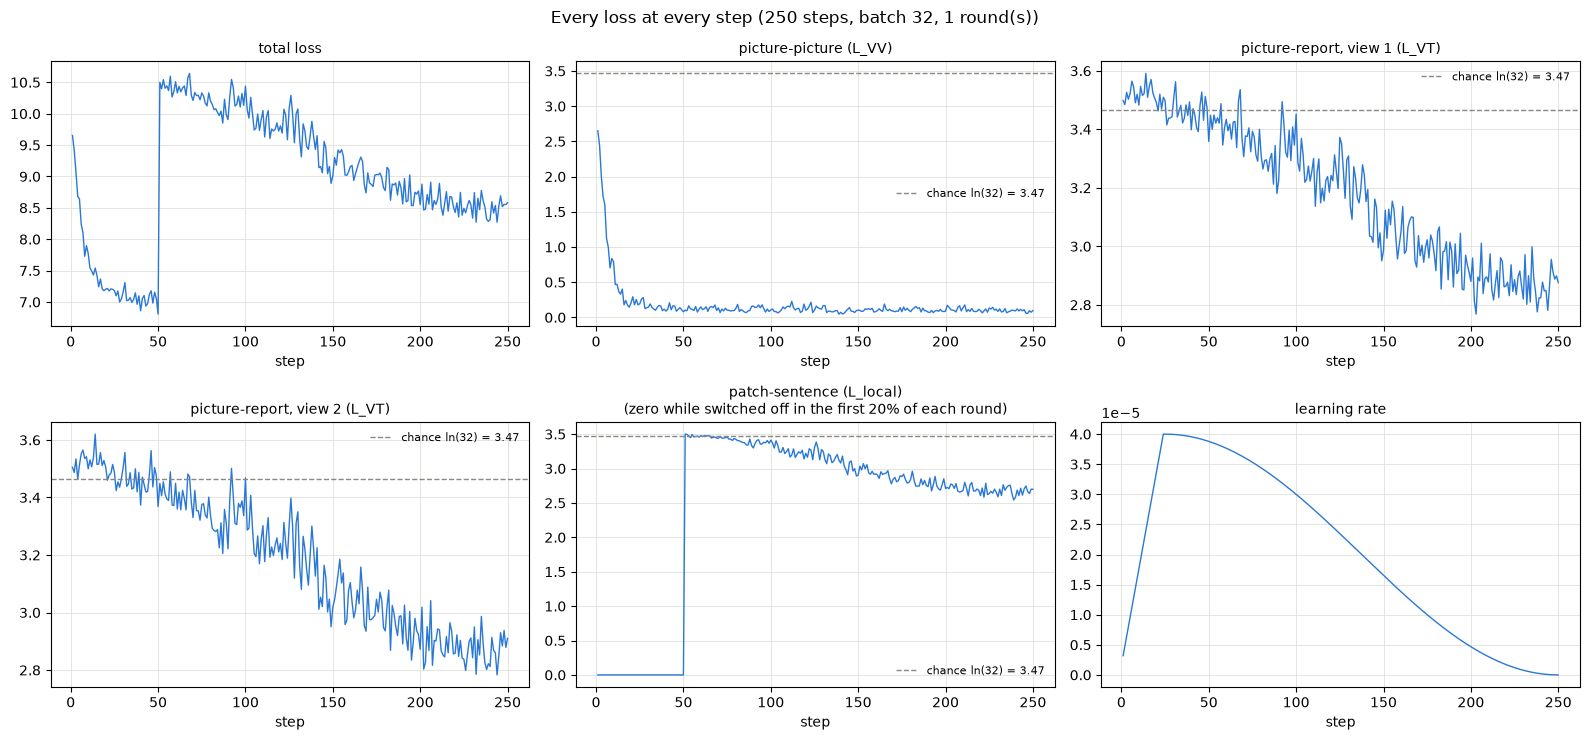

first step : {'total': 9.653, 'vv': 2.65, 'vt1': 3.498, 'vt2': 3.505, 'local': 0.0}
last step  : {'total': 8.582, 'vv': 0.097, 'vt1': 2.876, 'vt2': 2.91, 'local': 2.699}


In [12]:
chance = np.log(BATCH)
fig, axes = plt.subplots(2, 3, figsize=(16, 7.5))
terms = [("total", "total loss"), ("vv", "picture-picture (L_VV)"), ("vt1", "picture-report, view 1 (L_VT)"),
         ("vt2", "picture-report, view 2 (L_VT)"), ("local", "patch-sentence (L_local)"), ("lr", "learning rate")]
for ax, (column, title) in zip(axes.ravel(), terms):
    ax.plot(history["global_step"], history[column], lw=1, color="#2a78d6")
    if column in ("vv", "vt1", "vt2", "local"):
        ax.axhline(chance, color="#898781", ls="--", lw=1, label=f"chance ln({BATCH}) = {chance:.2f}")
        ax.legend(frameon=False, fontsize=8)
    if column == "local":
        ax.set_title(title + "\n(zero while switched off in the first 20% of each round)", fontsize=10)
    else:
        ax.set_title(title, fontsize=10)
    for boundary in rounds["steps_total"].iloc[:-1]:
        ax.axvline(boundary, color="#e1e0d9", lw=1)
    ax.set_xlabel("step")
    ax.grid(True, color="#e1e0d9", lw=0.6)
plt.suptitle(f"Every loss at every step ({len(history)} steps, batch {BATCH}, {len(rounds)} round(s))")
plt.tight_layout()
plt.savefig(OUT / "losses.png", dpi=120)
plt.show()
first, last = history.iloc[0], history.iloc[-1]
print("first step :", {k: round(float(first[k]), 3) for k in ("total", "vv", "vt1", "vt2", "local")})
print("last step  :", {k: round(float(last[k]), 3) for k in ("total", "vv", "vt1", "vt2", "local")})

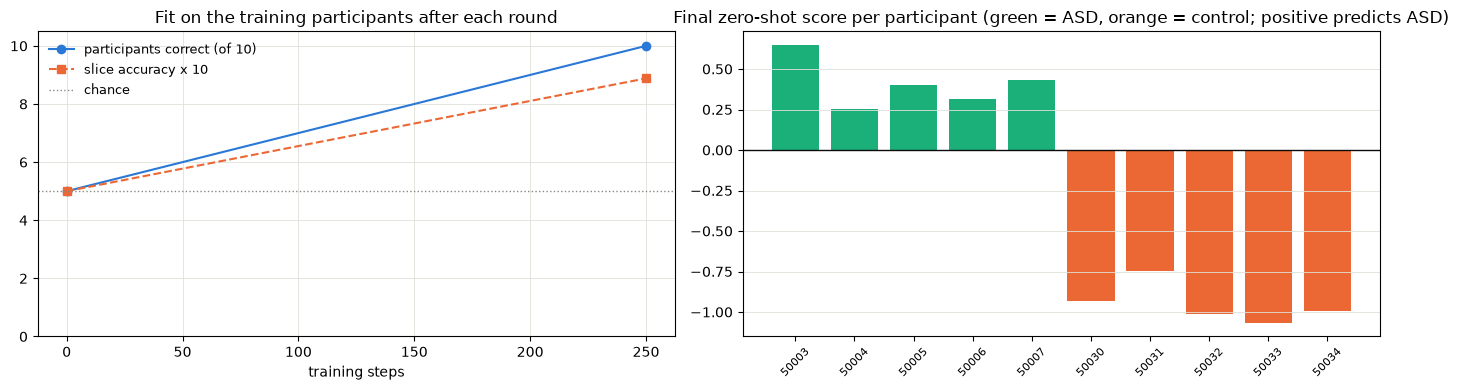

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
x = [0] + rounds["steps_total"].tolist()
axes[0].plot(x, [metrics_initial["accuracy"] * 10] + rounds["participants_correct"].tolist(), "o-", color="#2a78d6", label="participants correct (of 10)")
axes[0].plot(x, [acc_slices_initial * 10] + (rounds["slice_accuracy"] * 10).tolist(), "s--", color="#eb6834", label="slice accuracy x 10")
axes[0].axhline(5, color="#898781", ls=":", lw=1, label="chance")
axes[0].set_xlabel("training steps")
axes[0].set_ylim(0, 10.5)
axes[0].set_title("Fit on the training participants after each round")
axes[0].legend(frameon=False, fontsize=9)
axes[0].grid(True, color="#e1e0d9", lw=0.6)

final_scores = rounds[[f"score_{fid}" for fid in file_ids]].iloc[-1].to_numpy()
colors = ["#1baf7a" if label else "#eb6834" for label in y]
axes[1].bar(range(10), final_scores, color=colors)
axes[1].axhline(0, color="#0b0b0b", lw=1)
axes[1].set_xticks(range(10))
axes[1].set_xticklabels([f.replace("Pitt_00", "") for f in file_ids], rotation=45, fontsize=8)
axes[1].set_title("Final zero-shot score per participant (green = ASD, orange = control; positive predicts ASD)")
axes[1].grid(True, axis="y", color="#e1e0d9", lw=0.6)
plt.tight_layout()
plt.savefig(OUT / "fit.png", dpi=120)
plt.show()

### Diagnostics (computed whether or not the fit succeeded)

Three things that would explain a failure to fit:

- **Prompt separation.** If the text tower maps the "autism" and "typical development"
  prompts to almost the same vector, the zero-shot comparison has nothing to work with.
- **Embedding collapse.** If every slice gets the same picture embedding, the picture tower
  has stopped carrying information.
- **Per-slice margins.** Whether misclassified participants are near the decision line or
  confidently wrong, and whether the two groups separate at the slice level at all.

ASD-vs-control prompt cosine: 0.9900 before training -> 0.9775 after (1.0 = indistinguishable)
mean cosine between slice embeddings: all pairs 0.048, same participant 0.254, different participants 0.026 (near 1.0 everywhere = collapse)


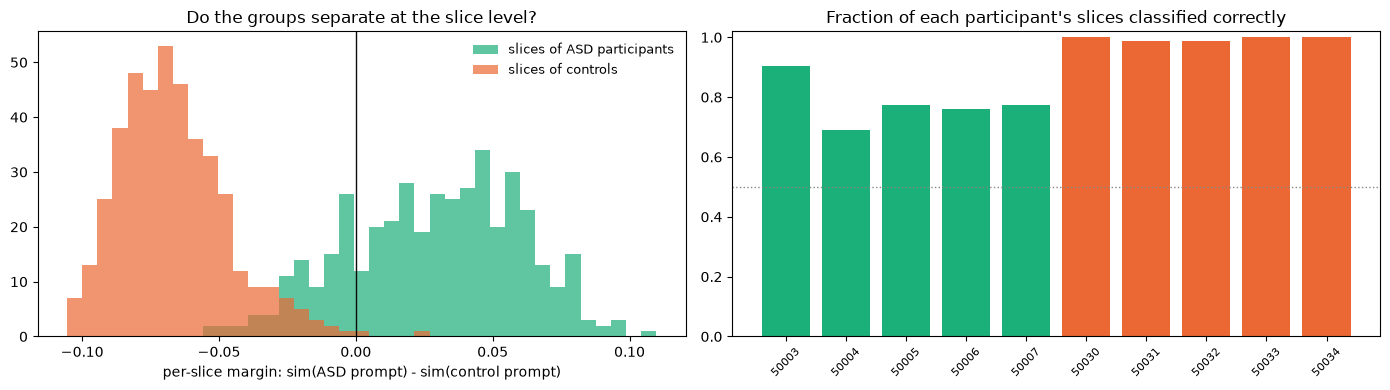

,FILE_ID,label,margin_mean,margin_min,margin_max,slices_correct
0,Pitt_0050003,1,0.045360,-0.046378,0.109688,0.904762
1,Pitt_0050004,1,0.017895,-0.054794,0.078066,0.690476
2,Pitt_0050005,1,0.027980,-0.044676,0.090068,0.773810
3,Pitt_0050006,1,0.021939,-0.052205,0.095996,0.761905
4,Pitt_0050007,1,0.030206,-0.034794,0.092370,0.773810
5,Pitt_0050030,0,-0.065554,-0.092235,-0.020977,1.000000
6,Pitt_0050031,0,-0.052505,-0.091301,0.026471,0.988095
7,Pitt_0050032,0,-0.070875,-0.100939,0.003833,0.988095
8,Pitt_0050033,0,-0.074714,-0.105478,-0.026195,1.000000
9,Pitt_0050034,0,-0.069602,-0.102611,-0.001648,1.000000


In [14]:
prompt_pair = vlm_reports.class_prompts(rows[file_ids[0]], "axial", 0.5)
emb = vlm_model.embed_reports(model, [prompt_pair[1], prompt_pair[0]], device)
prompt_cos_after = float(emb[0] @ emb[1])

embeddings = {fid: vlm_model.embed_images(model, vlm_experiment.subject_slices(banks[fid], PLANES, N_TIMEPOINTS_EVAL)[0], IMAGE_SIZE, device)["global"] for fid in file_ids}
stacked = np.concatenate(list(embeddings.values()))
owner = np.concatenate([[i] * len(e) for i, e in enumerate(embeddings.values())])
gram = stacked @ stacked.T
off_diagonal = ~np.eye(len(gram), dtype=bool)
same = (owner[:, None] == owner[None, :]) & off_diagonal
mean_cos_all = float(gram[off_diagonal].mean())
mean_cos_within = float(gram[same].mean())
mean_cos_between = float(gram[~same & off_diagonal].mean())

margins = {fid: slice_margins(model, fid, rows) for fid in file_ids}
print(f"ASD-vs-control prompt cosine: {prompt_cos_before:.4f} before training -> {prompt_cos_after:.4f} after (1.0 = indistinguishable)")
print(f"mean cosine between slice embeddings: all pairs {mean_cos_all:.3f}, same participant {mean_cos_within:.3f}, "
      f"different participants {mean_cos_between:.3f} (near 1.0 everywhere = collapse)")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
asd_margins = np.concatenate([margins[f] for f, label in zip(file_ids, y) if label == 1])
control_margins = np.concatenate([margins[f] for f, label in zip(file_ids, y) if label == 0])
bins = np.linspace(min(asd_margins.min(), control_margins.min()), max(asd_margins.max(), control_margins.max()), 40)
axes[0].hist(asd_margins, bins=bins, alpha=0.7, color="#1baf7a", label="slices of ASD participants")
axes[0].hist(control_margins, bins=bins, alpha=0.7, color="#eb6834", label="slices of controls")
axes[0].axvline(0, color="#0b0b0b", lw=1)
axes[0].set_xlabel("per-slice margin: sim(ASD prompt) - sim(control prompt)")
axes[0].set_title("Do the groups separate at the slice level?")
axes[0].legend(frameon=False, fontsize=9)
per_subject = pd.DataFrame({"FILE_ID": file_ids, "label": y,
                            "margin_mean": [margins[f].mean() for f in file_ids],
                            "margin_min": [margins[f].min() for f in file_ids],
                            "margin_max": [margins[f].max() for f in file_ids],
                            "slices_correct": [float(((margins[f] > 0).astype(int) == label).mean()) for f, label in zip(file_ids, y)]})
axes[1].bar(range(10), per_subject["slices_correct"], color=colors)
axes[1].axhline(0.5, color="#898781", ls=":", lw=1)
axes[1].set_xticks(range(10))
axes[1].set_xticklabels([f.replace("Pitt_00", "") for f in file_ids], rotation=45, fontsize=8)
axes[1].set_ylim(0, 1.02)
axes[1].set_title("Fraction of each participant's slices classified correctly")
plt.tight_layout()
plt.savefig(OUT / "diagnostics.png", dpi=120)
plt.show()
display(per_subject)

## 5. Save the model, load it again, predict without the diagnosis

The model is saved exactly as `vlm_experiment.py --save-models` does (`torch.save` of the
state dict). A **fresh** model is then built from the pre-trained towers and the saved
weights are loaded into it with strict key matching, so any missing or unexpected weight
(for example a LoRA adapter that was not saved) would raise.

For the re-prediction, every participant's record has `DX_GROUP`, `DSM_IV_TR`, `ADOS_TOTAL`
and `ADOS_GOTHAM_SEVERITY` blanked. The zero-shot protocol builds both candidate prompts
from the remaining metadata, so if the predictions still match, the diagnosis demonstrably
played no part in them. A third, untrained model is scored the same way to show the saved
weights are what carries the predictions.

In [15]:
model_path = OUT / "pitt10_mama.pt"
torch.save({k: v.cpu() for k, v in model.state_dict().items()}, model_path)
print(f"saved {model_path.name}: {model_path.stat().st_size / 2**20:.0f} MB, {len(model.state_dict())} tensors")

reloaded = build_model()
result = reloaded.load_state_dict(torch.load(model_path, map_location="cpu"), strict=True)
assert not result.missing_keys and not result.unexpected_keys, result
reloaded.to(device).eval()

blind = {}
for fid in file_ids:
    record = rows[fid].copy()
    for column in ("DX_GROUP", "DSM_IV_TR", "ADOS_TOTAL", "ADOS_GOTHAM_SEVERITY"):
        record[column] = np.nan
    blind[fid] = record
assert all(vlm_reports.subject_fields(blind[f])["asd"] is False and vlm_reports.subject_fields(blind[f])["ados_total"] is None for f in file_ids)

scores_trained, metrics_trained = evaluate(model, rows)
scores_reloaded, metrics_reloaded = evaluate(reloaded, blind)
fresh = build_model().to(device).eval()
scores_fresh, metrics_fresh = evaluate(fresh, blind)
del fresh

max_abs_diff = float(np.abs(scores_trained - scores_reloaded).max())
same_predictions = bool(((scores_trained > 0) == (scores_reloaded > 0)).all())
weights_matter = not np.allclose(scores_trained, scores_fresh, atol=1e-3)
comparison = pd.DataFrame({"FILE_ID": file_ids, "label": y, "trained_model": scores_trained,
                           "reloaded_model_blind_records": scores_reloaded, "untrained_model_blind_records": scores_fresh})
display(comparison)
print(f"max |trained - reloaded| = {max_abs_diff:.2e}; identical predicted labels: {same_predictions}; "
      f"untrained model differs: {weights_matter}")
print(f"participants correct: trained {int(round(metrics_trained['accuracy'] * 10))}/10, "
      f"reloaded (blind) {int(round(metrics_reloaded['accuracy'] * 10))}/10, untrained {int(round(metrics_fresh['accuracy'] * 10))}/10")

saved pitt10_mama.pt: 501 MB, 479 tensors


,FILE_ID,label,trained_model,reloaded_model_blind_records,untrained_model_blind_records
0,Pitt_0050003,1,0.646941,0.646941,-0.175785
1,Pitt_0050004,1,0.255225,0.255225,-0.167426
2,Pitt_0050005,1,0.399053,0.399053,-0.168251
3,Pitt_0050006,1,0.312903,0.312903,-0.151079
4,Pitt_0050007,1,0.430807,0.430807,-0.193917
5,Pitt_0050030,0,-0.934940,-0.934940,-0.236657
6,Pitt_0050031,0,-0.748836,-0.748836,-0.183277
7,Pitt_0050032,0,-1.010841,-1.010841,-0.167230
8,Pitt_0050033,0,-1.065588,-1.065588,-0.179054
9,Pitt_0050034,0,-0.992676,-0.992676,-0.174783


max |trained - reloaded| = 0.00e+00; identical predicted labels: True; untrained model differs: True
participants correct: trained 10/10, reloaded (blind) 10/10, untrained 5/10


## 6. Verdict

Every check below must pass for the pipeline to "work" on these ten participants. The
report in `results/pitt10_check/report.md` repeats this table and, if anything failed, a
diagnosis built from the numbers above.

In [16]:
def df_to_md(df):
    # a markdown table without the tabulate package, which the venv does not have
    def cell(v):
        return f"{v:.4g}" if isinstance(v, (float, np.floating)) else str(v)
    head = "| " + " | ".join(df.columns) + " |"
    sep = "|" + "---|" * len(df.columns)
    body = ["| " + " | ".join(cell(v) for v in row) + " |" for row in df.itertuples(index=False)]
    return "\n".join([head, sep] + body)


chance = float(np.log(BATCH))
last10 = history.tail(10).mean(numeric_only=True)
first10 = history.head(10).mean(numeric_only=True)
core_first = float(first10["vv"] + first10["vt1"] + first10["vt2"])  # the local term is off at the start, so compare the rest
core_last = float(last10["vv"] + last10["vt1"] + last10["vt2"])
vt_last = float(0.5 * (last10["vt1"] + last10["vt2"]))
checks = [
    ("data", "10 participants, 5 ASD + 5 control, 3 planes x 16 x 7 slices each", len(banks) == 10 and int(y.sum()) == 5),
    ("inputs", "no report or prompt longer than the 160-token limit", longest <= 160),
    ("inputs", "label sentence present in every tokenised report", all_labels_present),
    ("inputs", "zero-shot prompts carry no mask token, ADOS or DSM text",
     all(not any(w in s for w in (vlm_reports.MASK_TOKEN, "ADOS", "DSM")) for p in (prompts[1], prompts[0]) for s in p)),
    ("training", "always-on terms (L_VV + 2 L_VT) ended below their starting value", core_last < core_first),
    ("training", "picture-report loss (L_VT) ended below chance ln(32)", float(0.5 * (last10["vt1"] + last10["vt2"])) < chance),
    ("training", "picture-picture loss (L_VV) ended below chance ln(32)", float(last10["vv"]) < chance),
    ("training", "patch-sentence loss (L_local) ended below chance ln(32)", float(last10["local"]) < chance),
    ("fit", "all 10 training participants classified correctly zero-shot", participants_fitted),
    ("fit", f"at least {SLICE_TARGET:.0%} of the training slices classified correctly", slices_fitted),
    ("save/load", "saved model reloads with strict key matching", True),
    ("save/load", "reloaded model, diagnosis blanked, gives the same scores (max diff < 1e-3)", max_abs_diff < 1e-3),
    ("save/load", "reloaded model gives the same predicted labels", same_predictions),
    ("save/load", "an untrained model gives different scores (the weights carry the result)", weights_matter),
]
verdict = pd.DataFrame(checks, columns=["stage", "check", "passed"])
verdict["result"] = np.where(verdict["passed"], "PASS", "FAIL")
display(verdict[["stage", "check", "result"]])
overall = bool(verdict["passed"].all())
print("\nOVERALL:", "PASS, the pipeline fits these ten participants and reproduces its predictions after reload"
      if overall else "FAIL, see the diagnosis below and in report.md")

diagnosis = []
if not fitted:
    diagnosis.append(f"The model did not fit within {len(history)} steps: {int(rounds['participants_correct'].iloc[-1])}/10 participants correct, "
                     f"slice accuracy {float(rounds['slice_accuracy'].iloc[-1]):.2f} (target {SLICE_TARGET}).")
    if participants_fitted and not slices_fitted:
        diagnosis.append("Every participant is on the right side on average, but individual slices are not memorised yet. "
                         "If the picture-report loss was still falling at the end (see losses.png), this is a training budget "
                         "issue (more steps, or a longer round so the learning rate does not decay to zero so early), not a pipeline fault.")
    if prompt_cos_after > 0.99:
        diagnosis.append(f"Likely cause: the text tower cannot separate the two prompts (cosine {prompt_cos_after:.4f}); "
                         "the label sentences are either truncated or the LoRA adapters / text head are not learning.")
    if vt_last > chance - 0.3:
        diagnosis.append("Likely cause: the picture-report loss never moved away from chance, so pictures were not matched to their reports; "
                         "check the picture-report pairing in PairDataset and the learning rate.")
    if mean_cos_between > 0.95:
        diagnosis.append(f"Likely cause: slice embeddings collapsed (mean cosine between participants {mean_cos_between:.3f}).")
    if vt_last <= chance - 0.3 and prompt_cos_after <= 0.99 and mean_cos_between <= 0.95:
        diagnosis.append("The losses did fall and the towers are not degenerate, so the remaining gap is most likely the amount of training; "
                         "the zero-shot protocol also averages over masked-free prompts the model saw unmasked only 20% of the time.")
if longest > 160 or not all_labels_present:
    diagnosis.append(f"Reports are truncated at 160 tokens (longest {longest}); the diagnosis sentences come last and are lost.")
if max_abs_diff >= 1e-3 or not same_predictions:
    diagnosis.append(f"Reloading changed the predictions (max difference {max_abs_diff:.2e}); the state dict does not capture every trained weight, "
                     "or evaluation is non-deterministic (dropout left on?).")
if not weights_matter:
    diagnosis.append("An untrained model gives the same scores as the trained one: training did not change what the evaluation uses.")

lines = [f"# Pipeline check on 10 PITT participants", "",
         f"Generated by notebooks/pitt10_pipeline_check.ipynb at commit {commit}{' (dirty)' if dirty else ''} on {device}, "
         f"{time.strftime('%Y-%m-%d %H:%M')}. Quick mode: {QUICK}.", "",
         f"**Overall: {'PASS' if overall else 'FAIL'}**", "",
         "## Participants", "", table[["FILE_ID", "label", "AGE_AT_SCAN", "SEX", "FIQ"]].pipe(df_to_md), "",
         "## Training", "",
         f"{len(history)} steps in {len(rounds)} round(s) of {STEPS_PER_ROUND}, batch {BATCH}, {IMAGE_SIZE} px, "
         f"{len(dataset)} slice-report pairs. Chance per InfoNCE term: ln({BATCH}) = {chance:.2f}.", "",
         "| term | mean of first 10 steps | mean of last 10 steps |", "|---|---|---|"]
for term in ("total", "vv", "vt1", "vt2", "local"):
    lines.append(f"| {term} | {float(first10[term]):.3f} | {float(last10[term]):.3f} |")
lines += ["", rounds[["round", "steps_total", "loss_total_last10", "participants_correct", "slice_accuracy", "auc", "seconds"]].pipe(df_to_md), "",
          "## Diagnostics", "",
          f"- ASD-vs-control prompt cosine: {prompt_cos_before:.4f} before training, {prompt_cos_after:.4f} after.",
          f"- Mean cosine between slice embeddings: same participant {mean_cos_within:.3f}, different participants {mean_cos_between:.3f}.",
          f"- Longest tokenised text: {longest} tokens of 160.", "",
          "## Save / reload", "", comparison.pipe(df_to_md), "",
          f"Max |trained - reloaded| = {max_abs_diff:.2e}; same predicted labels: {same_predictions}; untrained model differs: {weights_matter}.", "",
          "## Checks", "", verdict[["stage", "check", "result"]].pipe(df_to_md), "",
          "## Diagnosis", ""]
lines += [f"- {d}" for d in diagnosis] if diagnosis else ["No problem found."]
lines += ["", "## Files", "", "- loss_history.csv, rounds.csv, participants.csv", "- losses.png, fit.png, diagnostics.png", "- pitt10_mama.pt (the saved model)"]
(OUT / "report.md").write_text("\n".join(lines) + "\n")
print(f"\nreport written to {OUT / 'report.md'}")

,stage,check,result
0,data,"10 participants, 5 ASD + 5 control, 3 planes x...",PASS
1,inputs,no report or prompt longer than the 160-token ...,PASS
2,inputs,label sentence present in every tokenised report,PASS
3,inputs,"zero-shot prompts carry no mask token, ADOS or...",PASS
4,training,always-on terms (L_VV + 2 L_VT) ended below th...,PASS
5,training,picture-report loss (L_VT) ended below chance ...,PASS
6,training,picture-picture loss (L_VV) ended below chance...,PASS
7,training,patch-sentence loss (L_local) ended below chan...,PASS
8,fit,all 10 training participants classified correc...,PASS
9,fit,at least 80% of the training slices classified...,PASS



OVERALL: PASS, the pipeline fits these ten participants and reproduces its predictions after reload

report written to /Users/tamilorebolodeoku/Documents/abide-replication/results/pitt10_check/report.md
